In [ ]:
%pip install gin-config
%pip install absl-py
%pip install gym==0.23.0
%pip install matplot

In [1]:
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'

In [2]:
from __future__ import absolute_import
from __future__ import division
from __future__ import print_function

import re
from concurrent.futures import ThreadPoolExecutor, as_completed
import tensorflow as tf
import numpy as np 
import numpy as np
import requests 
import time

# TF‑Agents imports  
from tf_agents.environments import tf_py_environment  
from tf_agents.trajectories import trajectory
from tf_agents.networks import q_network
from tf_agents.agents.dqn import dqn_agent
from tf_agents.utils import common
from tf_agents.replay_buffers import tf_uniform_replay_buffer 
from tf_agents.policies import epsilon_greedy_policy

from tf_agents.environments import py_environment
from tf_agents.specs import array_spec
from tf_agents.trajectories import time_step as ts

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [3]:
def getResponseFromServer():
    url = 'http://localhost:8005'

    try:
        response = requests.get(url)

        if response.status_code == 200:
            print("Successfully received response from load balancer")
            return
        else:
            print('Error:', response.status_code)
            return None
    except requests.exceptions.RequestException as e:
        print(f"An error occurred: {e}")
        return None

In [4]:
getResponseFromServer()

Successfully received response from load balancer


## REWARD-4 — Adaptive SLA-Penalized Reliability Reward

### Novelty over REWARD-1/2/3

| | REWARD-1 | REWARD-2 | REWARD-3 | **REWARD-4 (this model)** |
|---|---|---|---|---|
| Latency signal | raw | raw | SLA threshold (binary) | **SLA threshold (quadratic)** |
| Failure signal | ✗ | linear penalty | linear penalty | **linear penalty** |
| Throughput | ✗ | unbounded term | ✗ | ✗ (avoids drift) |
| Load fairness | ✗ | ✗ | ✗ | **entropy bonus** |
| Normalization | ✗ | ✗ | ✗ | **all inputs [0,1]** |

### Formula

```
violation    = max(0, latency_norm - sla_norm)           # 0 when within SLA
latency_pen  = alpha * violation^2                       # quadratic — punishes severe violations harder
failure_pen  = beta  * failure_ratio
fairness_bon = lambda * H(pi)   where H = -sum(p_i * log(p_i + eps))

r4 = - latency_pen - failure_pen + fairness_bon
```

**Why quadratic?**  REWARD-3 uses `max(0, lat - sla)` (linear beyond threshold).
A quadratic term makes the penalty grow super-linearly with violation severity,
giving the agent a strong gradient signal to avoid egregious SLA breaches
while remaining insensitive to tiny fluctuations near the threshold.

**Why an entropy bonus?**  The entropy H of the agent's server-selection
distribution over a rolling window rewards balanced routing.
When the agent monopolises one server (H → 0), the bonus collapses,
counteracting the monopolisation failure mode seen in REWARD-1 and REWARD-2.
The bonus is bounded to [0, log(N)] so it can never dominate the penalty terms.


In [5]:
SERVER_METRICS_URL = "http://localhost:8005/server-metrics"
SERVERS = [
    "http://127.0.0.1:8000",
    "http://127.0.0.1:8001",
    "http://127.0.0.1:8002",
]

In [6]:
def _parse_prometheus_metrics(metrics_text: str) -> dict:
    """Extract aggregated metrics from Prometheus text format."""
    failed_count_match = re.search(
        r'flask_http_request_total\{method="GET",status="429"\}\s+([\d.]+)', metrics_text)
    failed_count = float(failed_count_match.group(1)) if failed_count_match else 0.0

    success_count_match = re.search(
        r'flask_http_request_total\{method="GET",status="200"\}\s+([\d.]+)', metrics_text)
    success_count = float(success_count_match.group(1)) if success_count_match else 0.0

    total_requests = failed_count + success_count

    success_sum_match = re.search(
        r'flask_http_request_duration_seconds_sum\{method="GET",path="/heavy-task",status="200"\}\s+([\d.]+)', metrics_text)
    success_sum = float(success_sum_match.group(1)) if success_sum_match else 0.0

    success_time_count_match = re.search(
        r'flask_http_request_duration_seconds_count\{method="GET",path="/heavy-task",status="200"\}\s+([\d.]+)', metrics_text)
    success_time_count = float(success_time_count_match.group(1)) if success_time_count_match else 0.0

    avg_success_response = success_sum / success_time_count if success_time_count > 0 else 0.0

    failed_to_success_ratio = failed_count / success_count if success_count > 0 else (float('inf') if total_requests > 0 else 0.5)

    return {
        "avg_successful_response_time": avg_success_response,
        "total_requests": total_requests,
        "failed_to_success_ratio": failed_to_success_ratio
    }

In [7]:
def generate_state(serverUrl):
    latency = []
    requests_handled = []
    failed_to_success_ratio = []

    for server in SERVERS:
        try:
            response = requests.get(f"{server}/metrics", timeout=2)
            response.raise_for_status()
            backend_metrics = _parse_prometheus_metrics(response.text)

            print(f"{server}: {backend_metrics}")

            raw_latency = backend_metrics.get("avg_successful_response_time", 0.0)
            latency.append(min(raw_latency / 5.0, 1.0))
            raw_requests = backend_metrics.get("total_requests", 0.0)
            requests_handled.append(min(raw_requests / 10000, 1.0))
            failed_to_success_ratio.append(backend_metrics.get("failed_to_success_ratio", 0.5))
        except requests.RequestException as e:
            print(f"Error fetching metrics from {server}: {e}")
            latency.append(1.0)
            requests_handled.append(0.0)
            failed_to_success_ratio.append(0.5)
      
    state = np.column_stack([latency, requests_handled, failed_to_success_ratio])
    return state.astype(np.float32)

In [8]:

state = generate_state(SERVER_METRICS_URL)
print("Generated state:\n", state)

http://127.0.0.1:8000: {'avg_successful_response_time': 0.0, 'total_requests': 0.0, 'failed_to_success_ratio': 0.5}
http://127.0.0.1:8001: {'avg_successful_response_time': 0.0, 'total_requests': 0.0, 'failed_to_success_ratio': 0.5}
http://127.0.0.1:8002: {'avg_successful_response_time': 0.0, 'total_requests': 0.0, 'failed_to_success_ratio': 0.5}
Generated state:
 [[0.  0.  0.5]
 [0.  0.  0.5]
 [0.  0.  0.5]]


In [9]:
# ---------------------------------------------------------------------------
# REWARD-4: Adaptive SLA-Penalized Reliability Reward with Entropy Fairness Bonus
# ---------------------------------------------------------------------------
#
# Inputs (all already normalized to [0, 1] by _generate_state):
#   state_row[0]  latency_norm   = raw_latency / MAX_LATENCY
#   state_row[1]  requests_norm  = total_requests / MAX_REQUESTS  (unused here)
#   state_row[2]  failure_ratio  ∈ [0, 1]
#
# Parameters:
#   alpha       weight on the quadratic SLA-violation penalty   (default 1.0)
#   beta        weight on the failure-ratio penalty              (default 0.5)
#   lam         weight on the entropy fairness bonus             (default 0.2)
#   sla_norm    SLA latency threshold, already normalized        (default 0.1 = 0.5 s / 5.0 s)
#   action_history  list of recent server indices for entropy    (updated externally)
#   n_servers   total number of servers                          (default 3)
#
# Formula:
#   violation   = max(0, latency_norm - sla_norm)
#   latency_pen = alpha * violation^2          ← quadratic: punishes severe breaches harder
#   failure_pen = beta  * failure_ratio
#   entropy_H   = -sum_i[ p_i * log(p_i + eps) ]  over rolling action_history
#   fairness_bon= lam   * entropy_H / log(n_servers)   ← normalized to [0, 1] range
#
#   r4 = -latency_pen - failure_pen + fairness_bon
#
# ---------------------------------------------------------------------------

_action_history = []   # module-level rolling window, reset each episode

def reset_action_history():
    global _action_history
    _action_history = []

def compute_reward4(state_row,chosen_index, alpha=0.5,beta=0.3,lam=0.5, sla_norm=0.1, n_servers=3, history_window=10):
    """
    REWARD-4: Adaptive SLA-Penalized Reliability Reward with Entropy Fairness Bonus.

    Args:
        state_row     (np.ndarray): Normalized [latency_norm, requests_norm, failure_ratio].
        chosen_index  (int)       : Index of the server selected this step.
        alpha         (float)     : Quadratic SLA violation penalty weight.
        beta          (float)     : Failure ratio penalty weight.
        lam           (float)     : Entropy fairness bonus weight.
        sla_norm      (float)     : Normalized SLA latency threshold (e.g. 0.1 = 0.5 s).
        n_servers     (int)       : Total number of servers (for entropy normalization).
        history_window(int)       : Rolling window size for entropy calculation.

    Returns:
        float: Scalar reward signal.
    """
    global _action_history

    latency_norm  = float(state_row[0])
    failure_ratio = float(state_row[2])

    # ── Quadratic SLA-violation penalty ─────────────────────────────────────
    violation   = max(0.0, latency_norm - sla_norm)
    latency_pen = alpha * (violation ** 2)

    # ── Failure-ratio penalty ────────────────────────────────────────────────
    failure_pen = beta * failure_ratio

    # ── Entropy fairness bonus ───────────────────────────────────────────────
    _action_history.append(chosen_index)
    if len(_action_history) > history_window:
        _action_history.pop(0)

    counts = np.bincount(_action_history, minlength=n_servers).astype(np.float32)
    probs  = counts / counts.sum()
    eps    = 1e-8
    H      = -np.sum(probs * np.log(probs + eps))          # raw Shannon entropy
    H_max  = np.log(n_servers)                             # maximum possible entropy
    fairness_bon = lam * (H / H_max) 

    reward = -latency_pen - failure_pen + fairness_bon

    latency_slack = max(0.0, sla_norm - latency_norm) / sla_norm   # 0→1 as latency drops below SLA
    health_factor = max(0.0, 1.0 - failure_ratio / 0.1)            # fades out as failure_ratio → 0.1
    bonus = 0.3 * latency_slack * health_factor
    reward += bonus

    return float(reward)

In [10]:
# ---------------------------------------------------------------------------
# Hyperparameters — identical to model2 for fair comparison
# ---------------------------------------------------------------------------
GAMMA                    = 0.99
NEURAL_NETWORK_HIDDEN_UNITS = (64, 64)
MAX_BUFFER_SIZE          = 10000
LEARNING_RATE            = 5e-5

# Reward-4 specific (documented for the paper)
REWARD4_ALPHA  = 0.2   # minimal — latency within SLA for all servers
REWARD4_BETA   = 0.3   # dominant — only differentiating signal
REWARD4_LAMBDA = 0.6   # meaningful fairness bonus that can push reward positive
REWARD4_SLA_NORM = 0.1   # 0.5 s threshold / 5.0 s MAX_LATENCY
REWARD4_HISTORY_WINDOW   = 10    # rolling window for entropy calculation

In [11]:
class LoadBalancerEnvModel4(py_environment.PyEnvironment):
    """
    RL environment for REWARD-4.
    Identical structure to model2 LoadBalancerEnv but uses compute_reward4().
    State normalization is applied inside _generate_state() so the Q-network
    always receives values in [0, 1] matching the BoundedArraySpec.
    """

    MAX_LATENCY  = 5.0      # seconds  — normalization cap
    MAX_REQUESTS = 10000.0  # requests — normalization cap

    def __init__(self, server_metrics_url, servers):
        super(LoadBalancerEnvModel4, self).__init__()
        self._servers            = servers
        self._num_servers        = len(servers)
        self._server_metrics_url = server_metrics_url

        # All 3 features normalized to [0, 1]
        self._observation_spec = array_spec.BoundedArraySpec(
            shape=(self._num_servers * 3,),   # flat: 9 values
            dtype=np.float32,
            minimum=0.0,
            maximum=1.0,
            name='observation'
        )
        self._action_spec = array_spec.BoundedArraySpec(
            shape=(),
            dtype=np.int32,
            minimum=0,
            maximum=self._num_servers - 1,
            name='action'
        )

        self._episode_ended = False
        self._step_count    = 0
        self._max_steps     = 100

        reset_action_history()
        self._state = self._generate_state()

    # ── specs ─────────────────────────────────────────────────────────────────
    def action_spec(self):      return self._action_spec
    def observation_spec(self): return self._observation_spec

    # ── state ─────────────────────────────────────────────────────────────────
    def _generate_state(self):
        """
        Fetch metrics and normalize to [0, 1]:
          latency_norm  = raw_latency  / MAX_LATENCY   (clamped)
          requests_norm = total_reqs   / MAX_REQUESTS  (clamped)
          failure_ratio already in [0, 1]
        """
        latency = []
        requests_handled = []
        failed_to_success_ratio = []

        for server in SERVERS:
            try:
                response = requests.get(f"{server}/metrics", timeout=2)
                response.raise_for_status()
                backend_metrics = _parse_prometheus_metrics(response.text)

                print(f"{server}: {backend_metrics}")

                raw_latency = backend_metrics.get("avg_successful_response_time", 1.0)
                latency.append(min(raw_latency / 5.0, 1.0))
                raw_requests = backend_metrics.get("total_requests", 0.0)
                requests_handled.append(min(raw_requests / 10000, 1.0))
                failed_to_success_ratio.append(backend_metrics.get("failed_to_success_ratio", 0.5))
            except requests.RequestException as e:
                print(f"Error fetching metrics from {server}: {e}")
                latency.append(1.0)
                requests_handled.append(0.0)
                failed_to_success_ratio.append(0.5)
    
        state = np.column_stack([latency, requests_handled, failed_to_success_ratio])
        return state.flatten().astype(np.float32) 

    # ── reset ─────────────────────────────────────────────────────────────────
    def _reset(self):
        self._episode_ended = False
        self._step_count    = 0
        reset_action_history()          # clear entropy window each episode
        self._state = self._generate_state()
        return ts.restart(self._state)

    # ── step ──────────────────────────────────────────────────────────────────
    def _step(self, action):
        if self._episode_ended:
            return self.reset()

        self._step_count += 1
        chosen_index  = int(action)
        chosen_server = self._servers[chosen_index]
        print(f"[Model4] Routing → {chosen_server}")

        # Send 50 requests: 70% to chosen, 30% spread across others
        total_requests      = 30
        chosen_requests     = int(total_requests * 0.7)
        remaining_requests = total_requests - chosen_requests  # 30% to others

        # Instead of all at once, send in small batches
        batch_size = 10
        delay_between_batches = 0.1  # 100ms

        other_indices  = [i for i in range(self._num_servers) if i != chosen_index]

        request_targets        = [f"{chosen_server}/heavy-task"] * chosen_requests
        for _ in range(total_requests - chosen_requests):
            request_targets.append(f"{self._servers[np.random.choice(other_indices)]}/heavy-task")

        # Send the requests concurrently using ThreadPoolExecutor
        responses = []
        for i in range(0, len(request_targets), batch_size):
            batch = request_targets[i:i + batch_size]
            with ThreadPoolExecutor(max_workers=batch_size) as executor:
                futures = [executor.submit(requests.get, target, timeout=5) for target in batch]
                for future in as_completed(futures):
                    try:
                        resp = future.result()
                        responses.append(resp.status_code)
                    except Exception as e:
                        responses.append(None)
            time.sleep(delay_between_batches)

        success_count = sum(1 for r in responses if r == 200)
        failure_count = sum(1 for r in responses if r is None or r != 200)

        print(f"Simulated traffic: {success_count} successes, {failure_count} failures.")

        new_state = self._generate_state()

        start = chosen_index * 3
        # REWARD-4 — uses normalized state + entropy over rolling action window
        reward = compute_reward4(
            state_row      = new_state[start:start+3],
            chosen_index   = chosen_index,
            alpha          = REWARD4_ALPHA,
            beta           = REWARD4_BETA,
            lam            = REWARD4_LAMBDA,
            sla_norm       = REWARD4_SLA_NORM,
            n_servers      = self._num_servers,
            history_window = REWARD4_HISTORY_WINDOW,
        )
        print(f"  reward4: {reward:.4f}")

        self._state = new_state

        if self._step_count >= self._max_steps:
            self._episode_ended = True
            return ts.termination(self._state, reward)
        return ts.transition(self._state, reward=reward, discount=0.99)

In [12]:
# Quick sanity check — run this with your servers live
env4 = LoadBalancerEnvModel4(SERVER_METRICS_URL, SERVERS)
init_ts = env4.reset()
print("Initial state (normalized):\n", init_ts.observation)

test_ts = env4._step(0)
print("After step 0 — state:\n", test_ts.observation)
print("After step 0 — reward4:", test_ts.reward)

http://127.0.0.1:8000: {'avg_successful_response_time': 0.0, 'total_requests': 0.0, 'failed_to_success_ratio': 0.5}
http://127.0.0.1:8001: {'avg_successful_response_time': 0.0, 'total_requests': 0.0, 'failed_to_success_ratio': 0.5}
http://127.0.0.1:8002: {'avg_successful_response_time': 0.0, 'total_requests': 0.0, 'failed_to_success_ratio': 0.5}
http://127.0.0.1:8000: {'avg_successful_response_time': 0.0, 'total_requests': 0.0, 'failed_to_success_ratio': 0.5}
http://127.0.0.1:8001: {'avg_successful_response_time': 0.0, 'total_requests': 0.0, 'failed_to_success_ratio': 0.5}
http://127.0.0.1:8002: {'avg_successful_response_time': 0.0, 'total_requests': 0.0, 'failed_to_success_ratio': 0.5}
Initial state (normalized):
 [0.  0.  0.5 0.  0.  0.5 0.  0.  0.5]
[Model4] Routing → http://127.0.0.1:8000
Simulated traffic: 25 successes, 5 failures.
http://127.0.0.1:8000: {'avg_successful_response_time': 0.352520056287176, 'total_requests': 21.0, 'failed_to_success_ratio': 0.3125}
http://127.0.0.1:

In [13]:
# ---------------------------------------------------------------------------
# Build TF-Agents environment and DQN agent
# ---------------------------------------------------------------------------
train_env = tf_py_environment.TFPyEnvironment(env4)

q_net4 = q_network.QNetwork(
    train_env.observation_spec(),
    train_env.action_spec(),
    fc_layer_params=NEURAL_NETWORK_HIDDEN_UNITS
)

optimizer4 = tf.keras.optimizers.Adam(learning_rate=5e-5, clipnorm=1.0)
train_step_counter = tf.Variable(0)

agent = dqn_agent.DqnAgent(
    train_env.time_step_spec(),
    train_env.action_spec(),
    q_network=q_net4,
    optimizer=optimizer4,
    gamma=GAMMA,
    target_update_tau = 1,
    target_update_period=100,
    td_errors_loss_fn=common.element_wise_huber_loss,
    train_step_counter=train_step_counter
)
agent.initialize()
print("Agent4 initialized.")


Agent4 initialized.


In [14]:
# ---------------------------------------------------------------------------
# Replay buffer and initial data collection
# ---------------------------------------------------------------------------

eval_env4 = LoadBalancerEnvModel4(SERVER_METRICS_URL, SERVERS)
eval_tf_env = tf_py_environment.TFPyEnvironment(eval_env4)

replay_buffer4 = tf_uniform_replay_buffer.TFUniformReplayBuffer(
    data_spec  = agent.collect_data_spec,
    batch_size = train_env.batch_size,
    max_length = MAX_BUFFER_SIZE
)

EPSILON_GREEDY_START = 1.0
EPSILON_GREEDY_END   = 0.1
EPSILON_DECAY_STEPS  = 2000

epsilon = tf.compat.v1.train.polynomial_decay(
    learning_rate=EPSILON_GREEDY_START,
    global_step=train_step_counter,
    decay_steps=EPSILON_DECAY_STEPS,
    end_learning_rate=EPSILON_GREEDY_END
)

collect_policy = epsilon_greedy_policy.EpsilonGreedyPolicy(
    agent.policy, epsilon=epsilon
)

def collect_step(environment, policy, buffer):
    time_step   = environment.current_time_step()
    action_step = policy.action(time_step)
    next_ts     = environment.step(action_step.action)
    traj        = trajectory.from_transition(time_step, action_step, next_ts)
    buffer.add_batch(traj)

INITIAL_COLLECT_STEPS = 500
print(f"Collecting {INITIAL_COLLECT_STEPS} initial steps...")
for _ in range(INITIAL_COLLECT_STEPS):
    collect_step(train_env, collect_policy, replay_buffer4)

BATCH_SIZE = 64
dataset4   = replay_buffer4.as_dataset(
    sample_batch_size = BATCH_SIZE,
    num_steps         = 2
).prefetch(3)
iterator4 = iter(dataset4)
print("Replay buffer ready.")

http://127.0.0.1:8000: {'avg_successful_response_time': 0.352520056287176, 'total_requests': 21.0, 'failed_to_success_ratio': 0.3125}
http://127.0.0.1:8001: {'avg_successful_response_time': 0.3981589199975133, 'total_requests': 5.0, 'failed_to_success_ratio': 0.0}
http://127.0.0.1:8002: {'avg_successful_response_time': 0.378734800091479, 'total_requests': 4.0, 'failed_to_success_ratio': 0.0}
http://127.0.0.1:8000: {'avg_successful_response_time': 0.352520056287176, 'total_requests': 21.0, 'failed_to_success_ratio': 0.3125}
http://127.0.0.1:8001: {'avg_successful_response_time': 0.3981589199975133, 'total_requests': 5.0, 'failed_to_success_ratio': 0.0}
http://127.0.0.1:8002: {'avg_successful_response_time': 0.378734800091479, 'total_requests': 4.0, 'failed_to_success_ratio': 0.0}
[Model4] Routing → http://127.0.0.1:8002
Simulated traffic: 14 successes, 16 failures.
http://127.0.0.1:8000: {'avg_successful_response_time': 0.3683269571712507, 'total_requests': 26.0, 'failed_to_success_rati

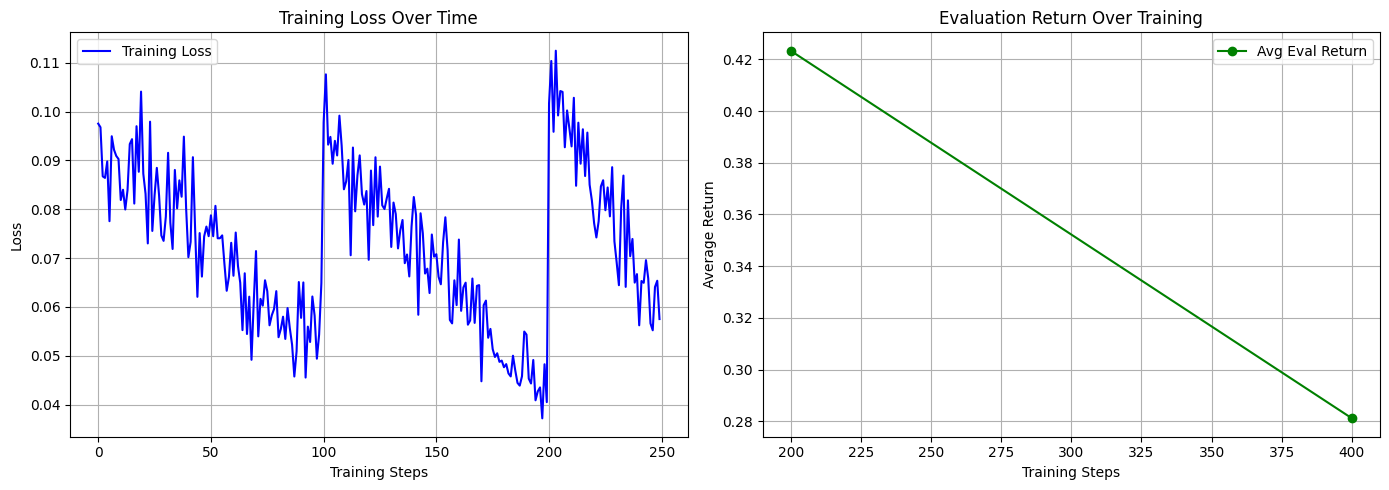

[Model4] Routing → http://127.0.0.1:8000
Simulated traffic: 25 successes, 5 failures.
http://127.0.0.1:8000: {'avg_successful_response_time': 0.3604396894161502, 'total_requests': 8548.0, 'failed_to_success_ratio': 0.06556968337073049}
http://127.0.0.1:8001: {'avg_successful_response_time': 0.3605363063698694, 'total_requests': 7845.0, 'failed_to_success_ratio': 0.3325972481739426}
http://127.0.0.1:8002: {'avg_successful_response_time': 0.3592504853012281, 'total_requests': 7157.0, 'failed_to_success_ratio': 1.214418316831683}
  reward4: 0.4996
[Model4] Routing → http://127.0.0.1:8000
Simulated traffic: 30 successes, 0 failures.
http://127.0.0.1:8000: {'avg_successful_response_time': 0.3604591344144792, 'total_requests': 8569.0, 'failed_to_success_ratio': 0.06539848315305234}
http://127.0.0.1:8001: {'avg_successful_response_time': 0.36057141927701014, 'total_requests': 7851.0, 'failed_to_success_ratio': 0.3322586119124385}
http://127.0.0.1:8002: {'avg_successful_response_time': 0.35933

KeyboardInterrupt: 

In [15]:
#new claude code for training

import matplotlib.pyplot as plt
import os
import numpy as np
from IPython.display import clear_output

plot_dir = "training_plots"
os.makedirs(plot_dir, exist_ok=True)

# ---------------------------------------------------------------------------
# 4. Training the Agent with Visualization
# ---------------------------------------------------------------------------

num_iterations = 800
train_loss_history = []
eval_returns_history = []       # NEW
eval_steps_history = []         # NEW: x-axis points for reward curve

eval_interval = 200              # NEW: evaluate every 50 steps
num_eval_episodes = 1         # NEW: average over 5 episodes for stability

def evaluate_agent(env, policy, num_episodes, max_eval_steps=20):
    """Run greedy policy for num_episodes, return average return."""
    total_return = 0.0
    for _ in range(num_episodes):
        time_step = env.reset()
        episode_return = 0.0
        step_count = 0.0
        while not time_step.is_last() and step_count < max_eval_steps:
            action_step = policy.action(time_step)
            time_step = env.step(action_step.action)
            episode_return += time_step.reward.numpy()[0]
            step_count += 1
        total_return += episode_return
    return total_return / num_episodes

consecutive_increase_count = 0
max_consecutive_increases = 5

plt.ion()

for step in range(num_iterations):
    collect_step(train_env, collect_policy, replay_buffer4)

    experience, unused_info = next(iterator4)
    train_loss = agent.train(experience).loss.numpy()

    train_loss_history.append(train_loss)
    train_step_counter.assign_add(1)

    # --- NEW: Evaluate every eval_interval steps ---
    current_step = train_step_counter.numpy()
    if current_step % eval_interval == 0:
        avg_return = evaluate_agent(eval_tf_env, agent.policy, num_eval_episodes)
        eval_returns_history.append(avg_return)
        eval_steps_history.append(current_step)
        print(f'Step = {current_step}: Loss = {train_loss:.4f} | Avg Return = {avg_return:.4f}')

    # Early stopping checks
    if len(train_loss_history) > 1 and train_loss > train_loss_history[-2]:
        consecutive_increase_count += 1
    else:
        consecutive_increase_count = 0

    if np.isnan(train_loss) or train_loss > 100.0:
        print("Stopping: Loss has diverged.")
        break

    # --- MODIFIED: Plot both curves every 100 steps ---
    if current_step % 100 == 0:
        clear_output(wait=True)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))  # side-by-side

        # Loss curve
        ax1.plot(train_loss_history, color="blue", label="Training Loss")
        ax1.set_xlabel("Training Steps")
        ax1.set_ylabel("Loss")
        ax1.set_title("Training Loss Over Time")
        ax1.legend()
        ax1.grid(True)

        # Reward curve
        if eval_returns_history:
            ax2.plot(eval_steps_history, eval_returns_history,
                     color="green", marker="o", label="Avg Eval Return")
            # Smoothed trend line
            if len(eval_returns_history) >= 5:
                smoothed = np.convolve(eval_returns_history,
                                       np.ones(5)/5, mode='valid')
                ax2.plot(eval_steps_history[4:], smoothed,
                         color="orange", linestyle="--", label="Smoothed (window=5)")
        ax2.set_xlabel("Training Steps")
        ax2.set_ylabel("Average Return")
        ax2.set_title("Evaluation Return Over Training")
        ax2.legend()
        ax2.grid(True)

        plt.tight_layout()
        plt.show()

        step_num = int(current_step // 10)
        fig.savefig(os.path.join(plot_dir, f"Output_{step_num}.png"))
        plt.close(fig)

plt.ioff()
print("Training completed successfully.")

# ---------------------------------------------------------------------------
# Final standalone reward plot (for paper)
# ---------------------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(eval_steps_history, eval_returns_history,
         color="green", marker="o", label="Avg Eval Return")
if len(eval_returns_history) >= 5:
    smoothed = np.convolve(eval_returns_history, np.ones(5)/5, mode='valid')
    plt.plot(eval_steps_history[4:], smoothed,
             color="orange", linestyle="--", label="Smoothed (window=5)")
plt.xlabel("Training Steps")
plt.ylabel("Average Return")
plt.title("Evaluation Return Over Training (HAMR Agent)")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(plot_dir, "eval_return_final.png"), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ---------------------------------------------------------------------------
# Save trained policy
# ---------------------------------------------------------------------------
policy_dir4 = "loadBalancingAlgorithms/saved_policies/load_balancing_trained_policy_model4"
os.makedirs(policy_dir4, exist_ok=True)

class ExportablePolicy(tf.Module):
    def __init__(self, policy):
        super().__init__()
        self.policy = policy

    @tf.function(input_signature=[
        ts.TimeStep(
            step_type   = tf.TensorSpec(shape=(1,), dtype=tf.int32,   name="step_type"),
            reward      = tf.TensorSpec(shape=(1,), dtype=tf.float32, name="reward"),
            discount    = tf.TensorSpec(shape=(1,), dtype=tf.float32, name="discount"),
            observation = tf.TensorSpec(shape=(1, 3, 3), dtype=tf.float32, name="observation")
        )
    ])
    def action(self, time_step):
        return self.policy.action(time_step).action

exportable4 = ExportablePolicy(agent.policy)
tf.saved_model.save(exportable4, policy_dir4)

# Verify
loaded4 = tf.saved_model.load(policy_dir4)
print("Policy saved to:", policy_dir4)
print("Signatures:", list(loaded4.signatures.keys()))